## Task 1
In this task, the grayscale image was enhanced using CLAHE (Contrast Limited Adaptive Histogram Equalization). Unlike standard histogram equalization, CLAHE works on small regions of the image instead of the whole image at once. This helps to improve local contrast and prevents over-amplification of noise in uniform areas.
First, the original image was loaded in grayscale format. Then, a CLAHE object was created with a specific clip limit and tile size. The algorithm redistributed the intensity values inside each small block of the image, which made dark regions brighter and improved details in low-contrast areas.
By comparing the original and enhanced images and their histograms, it can be seen that the enhanced image has a more balanced distribution of intensities, which results in better visual contrast and clearer details.

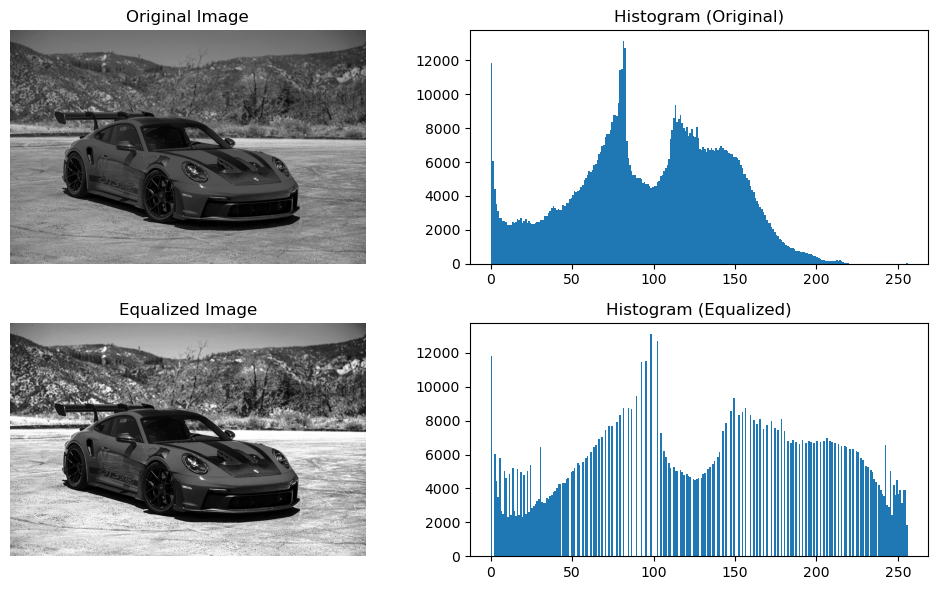

In [11]:
import cv2
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("porsche.jpg", cv2.IMREAD_GRAYSCALE)

equalized = cv2.equalizeHist(image)

plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.hist(image.ravel(), 256, [0, 256])
plt.title("Histogram (Original)")

plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.hist(equalized.ravel(), 256, [0, 256])
plt.title("Histogram (Equalized)")

plt.tight_layout()
plt.show()

## Task 2
For color images, applying histogram equalization directly to the RGB channels can distort the colors. To avoid this problem, the image was first converted from the BGR color space to the YCrCb color space, where the Y channel represents brightness and the Cr and Cb channels represent color information.
Histogram equalization was applied only to the Y (luminance) channel, while the color channels were left unchanged. After that, the channels were merged back and converted to the original color space.
This method improves the brightness and contrast of the image without changing its natural colors. The result shows better illumination and visibility of details while preserving the original color balance.

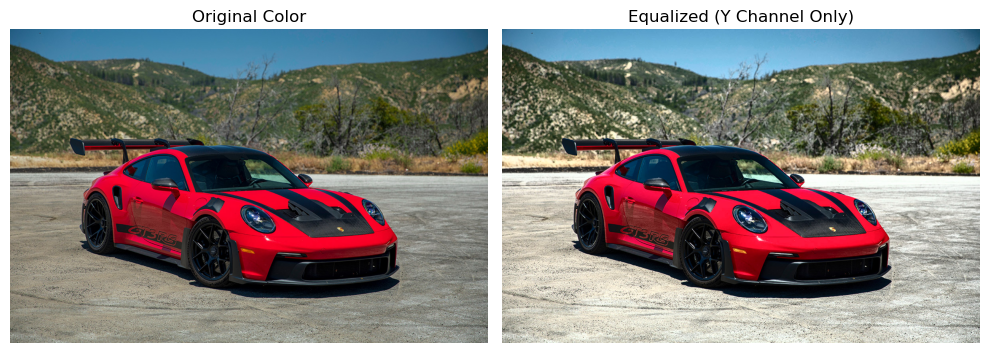

In [12]:
import cv2
import matplotlib.pyplot as plt

img_color = cv2.imread("porsche.jpg")

ycrcb = cv2.cvtColor(img_color, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)

y_eq = cv2.equalizeHist(y)

ycrcb_eq = cv2.merge([y_eq, cr, cb])
result = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2BGR)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Original Color")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Equalized (Y Channel Only)")
plt.axis("off")

plt.tight_layout()
plt.show()

## Task 3
In this task, histogram matching was performed to make the intensity distribution of the source image similar to the target image. Instead of using a ready-made library function, the cumulative distribution function (CDF) of both images was computed manually.
First, histograms of the source and target images were calculated. Then, their cumulative sums were normalized to obtain the CDFs. A lookup table was created by matching each intensity level of the source image to the closest intensity level in the target image based on their CDF values.
After applying this mapping, the resulting image has a histogram shape closer to the target image. Visually, this means that the brightness and contrast of the source image become more similar to those of the target image.

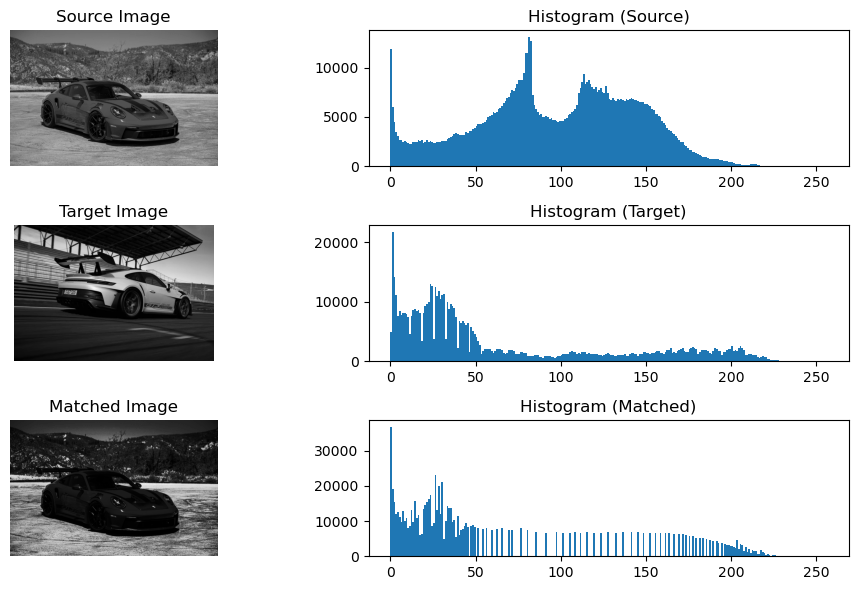

In [13]:
import cv2
import matplotlib.pyplot as plt
from skimage import exposure

# Read images in grayscale
source = cv2.imread("porsche.jpg", cv2.IMREAD_GRAYSCALE)
target = cv2.imread("pporsche.jpg", cv2.IMREAD_GRAYSCALE)

matched = exposure.match_histograms(source, target)

plt.figure(figsize=(15, 6))

plt.subplot(3, 3, 1)
plt.imshow(source, cmap="gray")
plt.title("Source Image")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.hist(source.ravel(), 256, [0, 256])
plt.title("Histogram (Source)")

plt.subplot(3, 3, 4)
plt.imshow(target, cmap="gray")
plt.title("Target Image")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.hist(target.ravel(), 256, [0, 256])
plt.title("Histogram (Target)")

plt.subplot(3, 3, 7)
plt.imshow(matched, cmap="gray")
plt.title("Matched Image")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.hist(matched.ravel(), 256, [0, 256])
plt.title("Histogram (Matched)")

plt.tight_layout()
plt.show()

## Task 4
In this part, two techniques were combined to further improve the image appearance. First, CLAHE was applied to the source image to enhance its local contrast and reveal more details. This step helps to normalize the brightness and improve visibility in dark or flat regions.
After that, histogram matching was applied to the enhanced image using the target image as a reference. This adjusts the intensity distribution of the enhanced image so that it more closely resembles the target image.
As a result, the final image benefits from both improved local contrast (due to CLAHE) and overall brightness and contrast similarity to the target image. This combination produces a visually more balanced and consistent image.

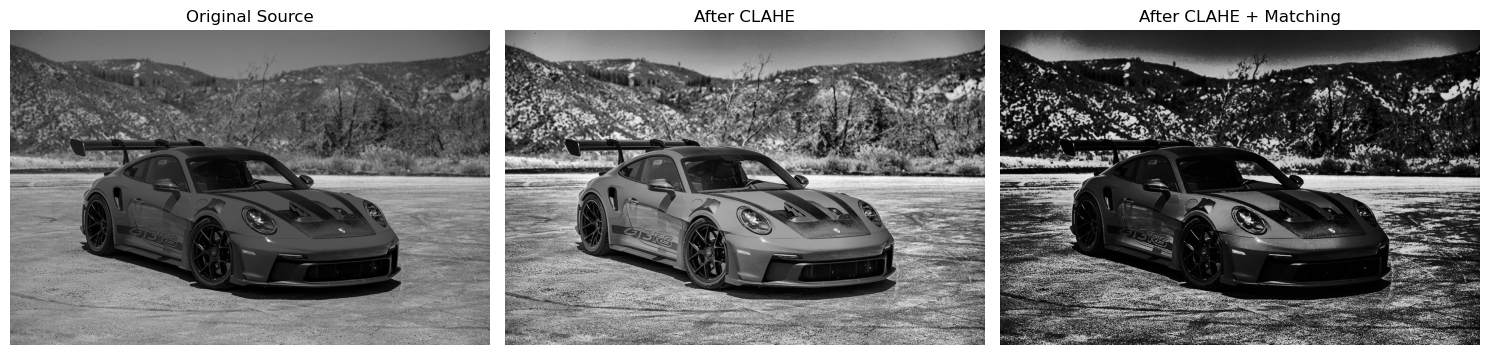

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read images
src = cv2.imread("porsche.jpg", cv2.IMREAD_GRAYSCALE)
tgt = cv2.imread("pporsche.jpg", cv2.IMREAD_GRAYSCALE)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
src_eq = clahe.apply(src)

src_hist, _ = np.histogram(src_eq.flatten(), 256, [0,256])
tgt_hist, _ = np.histogram(tgt.flatten(), 256, [0,256])

src_cdf = src_hist.cumsum() / src_hist.sum()
tgt_cdf = tgt_hist.cumsum() / tgt_hist.sum()

lut = np.zeros(256, dtype=np.uint8)
j = 0
for i in range(256):
    while j < 255 and tgt_cdf[j] < src_cdf[i]:
        j += 1
    lut[i] = j

final = cv2.LUT(src_eq, lut)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(src, cmap="gray")
plt.title("Original Source")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(src_eq, cmap="gray")
plt.title("After CLAHE")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final, cmap="gray")
plt.title("After CLAHE + Matching")
plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion
In this lab, different histogram-based image enhancement techniques were implemented. CLAHE was used to improve local contrast in grayscale images, and histogram equalization was applied to the luminance channel of color images to enhance brightness without color distortion. Histogram matching was also implemented using a manual CDF-based method to match the intensity distribution of one image to another. Finally, combining contrast enhancement and histogram matching produced a more visually consistent and improved image. These methods demonstrate how histogram processing can significantly improve image quality under different lighting conditions.